# LangGraph Multi-Agent Supervisor for Delta Shares

A supervisor agent routes tasks to three specialized sub-agents — Schema Explorer, Query Agent, and Summary Agent — each equipped with Spark SQL tools to discover, query, and profile Delta Share data.

In [0]:
import importlib, subprocess
_needed = [p for p in ["langgraph", "langchain_databricks", "langchain"]
           if importlib.util.find_spec(p) is None]
if _needed:
    subprocess.check_call(
        ["pip", "install", "langgraph", "langchain-databricks", "langchain", "-q"]
    )
    print(f"Installed: {_needed}")
else:
    print("All dependencies already installed")

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import json
from typing import Literal

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_databricks import ChatDatabricks
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import create_react_agent
from langgraph.types import Command
from pyspark.sql import functions as F

# Change the endpoint to match your model serving endpoint
llm = ChatDatabricks(endpoint="databricks-meta-llama-3-3-70b-instruct")


In [0]:
# Capture SparkSession for reliable use inside @tool functions on serverless
_spark = spark

# ── Schema Explorer tools ──────────────────────────────────

@tool
def list_shared_catalogs() -> str:
    """List all catalogs, including those from Delta Sharing providers."""
    df = _spark.sql("SHOW CATALOGS")
    return json.dumps({"catalogs": [r.catalog for r in df.collect()]})

@tool
def describe_catalog(catalog_name: str) -> str:
    """List schemas and tables inside a catalog (including shared catalogs)."""
    try:
        schemas = [
            r.databaseName
            for r in _spark.sql(f"SHOW SCHEMAS IN `{catalog_name}`").collect()
        ]
        result = []
        for s in schemas:
            tables = [
                r.tableName
                for r in _spark.sql(
                    f"SHOW TABLES IN `{catalog_name}`.`{s}`"
                ).collect()
            ]
            result.append({"schema": s, "tables": tables})
        return json.dumps({"catalog": catalog_name, "schemas": result})
    except Exception as e:
        return json.dumps({"error": str(e)})


# ── Query Agent tools ──────────────────────────────────────

@tool
def get_table_schema(full_table_name: str) -> str:
    """Return columns and types for a table. Use catalog.schema.table format."""
    try:
        df = _spark.sql(f"DESCRIBE TABLE {full_table_name}")
        cols = [
            {"name": r.col_name, "type": r.data_type}
            for r in df.collect()
            if not r.col_name.startswith("#")
        ]
        return json.dumps({"table": full_table_name, "columns": cols})
    except Exception as e:
        return json.dumps({"error": str(e)})

@tool
def run_query(sql: str) -> str:
    """Execute a read-only SQL query and return up to 20 sample rows."""
    try:
        rows = _spark.sql(sql).limit(20).toPandas().to_dict(orient="records")
        return json.dumps({"rows": rows}, default=str)
    except Exception as e:
        return json.dumps({"error": str(e)})


# ── Summary Agent tools ────────────────────────────────────

@tool
def profile_table(full_table_name: str) -> str:
    """Profile a table: row count, null rates, and descriptive stats (first 10 cols)."""
    try:
        df = _spark.table(full_table_name)
        count = df.count()
        cols = df.columns[:10]
        nulls = {c: df.where(F.col(c).isNull()).count() for c in cols}
        stats = df.select(cols).describe().toPandas().to_dict(orient="records")
        return json.dumps(
            {"table": full_table_name, "rows": count, "nulls": nulls, "stats": stats},
            default=str,
        )
    except Exception as e:
        return json.dumps({"error": str(e)})

@tool
def compare_tables(table_a: str, table_b: str) -> str:
    """Compare row counts and schemas of two tables."""
    try:
        a, b = _spark.table(table_a), _spark.table(table_b)
        a_cols, b_cols = a.columns, b.columns
        return json.dumps(
            {
                "a": {"name": table_a, "rows": a.count(), "cols": a_cols},
                "b": {"name": table_b, "rows": b.count(), "cols": b_cols},
                "shared_cols": sorted(set(a_cols) & set(b_cols)),
            },
            default=str,
        )
    except Exception as e:
        return json.dumps({"error": str(e)})

In [0]:
import re
from pyspark.sql.functions import col, count, when, lit

# ── Precompute confidence table once ──────────────────────────
_company_confidence = (
    _spark.read.table("bdc_share_cash_flow.cashflow.cashflow")
        .groupBy("CompanyCode")
        .agg(count("*").alias("record_count"))
        .withColumn("confidence",
            when(col("record_count") < 100, lit("LOW"))
            .when(col("record_count") < 1000, lit("MEDIUM"))
            .otherwise(lit("HIGH"))
        )
)
_confidence_map = {r.CompanyCode: (r.confidence, r.record_count)
                   for r in _company_confidence.collect()}

# ── Output guardrail ──────────────────────────────────────
FORBIDDEN_ASSERTIONS = [
    r"\bconfirmed\s+fraud\b",
    r"\bdefinitely\s+fraud\b",
    r"\bmoney\s+laundering\s+is\s+occurring\b",
]
REQUIRED_HEDGE_TERMS = ["may", "might", "possibly", "could", "suggests", "indicates"]


def guardrail_node(state):
    """Post-process the last AI message: block forbidden claims, add confidence flags."""
    # Find the last substantive AI message (skip short completion markers)
    target_msg = None
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage) and len(msg.content) > 40:
            target_msg = msg
            break
    if target_msg is None:
        return {}

    text = target_msg.content
    violations = [p for p in FORBIDDEN_ASSERTIONS if re.search(p, text, re.IGNORECASE)]
    has_hedge = any(t in text.lower() for t in REQUIRED_HEDGE_TERMS)

    # Detect which company codes are referenced
    mentioned_companies = re.findall(
        r"\b(1010|1710|1110|3010|AUC1|USC1|DEC1|USC2|L100|R100|R300|LRE1)\b", text
    )
    confidence_notes = []
    for cc in set(mentioned_companies):
        if cc in _confidence_map:
            conf, cnt = _confidence_map[cc]
            confidence_notes.append(f"{cc}: {conf} ({cnt:,} records)")

    # Build guarded output
    if violations:
        wrapped = f"[BLOCKED by guardrail: {violations}]\n\nOriginal: {text}"
    else:
        prefix_parts = []
        if confidence_notes:
            prefix_parts.append(f"[Data Confidence: {', '.join(confidence_notes)}]")
        if not has_hedge and confidence_notes:
            prefix_parts.append("[WARN: answer lacks hedge terms]")
        wrapped = " ".join(prefix_parts) + "\n\n" + text if prefix_parts else text

    return {"messages": [AIMessage(content=wrapped)]}


print(f"\u2713 Guardrail loaded \u2014 {len(_confidence_map)} company codes mapped")

✓ Guardrail loaded — 18 company codes mapped


In [0]:
# ── Sub-agents ─────────────────────────────────────────────

schema_explorer = create_react_agent(
    llm,
    tools=[list_shared_catalogs, describe_catalog],
    prompt=(
        "You are the Schema Explorer. List available catalogs, then "
        "describe only the most relevant ones (at most 3). Do NOT "
        "describe every catalog. Always use your tools."
    ),
)

query_agent = create_react_agent(
    llm,
    tools=[get_table_schema, run_query],
    prompt=(
        "You are the Query Agent. Inspect table schemas and run SQL "
        "against shared tables. Always check schemas first. "
        "Use fully qualified names (catalog.schema.table)."
    ),
)

summary_agent = create_react_agent(
    llm,
    tools=[profile_table, compare_tables],
    prompt=(
        "You are the Summary Agent. Profile shared tables, compute stats, "
        "and compare datasets. Give clear, concise findings."
    ),
)


# ── Supervisor routing ─────────────────────────────────────

AGENT_NAMES = {"schema_explorer", "query_agent", "summary_agent"}


MAX_DELEGATION_ROUNDS = 3  # safety valve — trace showed 1 round suffices for simple tasks


def supervisor(
    state: MessagesState,
) -> Command[Literal["schema_explorer", "query_agent", "summary_agent", "guardrail"]]:
    """Decide which sub-agent should act next, or finish."""
    messages = state["messages"]

    # Force finish after too many rounds to avoid recursion blow-up
    ai_count = sum(1 for m in messages if isinstance(m, AIMessage))
    if ai_count >= MAX_DELEGATION_ROUNDS:
        return Command(
            goto="guardrail",
            update={"messages": [AIMessage(content="All tasks complete (max rounds).")]},
        )

    sys = SystemMessage(
        content=(
            "You are a supervisor routing between: schema_explorer, query_agent, summary_agent.\n"
            "CRITICAL RULES:\n"
            "1. If the last message contains a complete answer OR says "
            "'I already did' OR 'task complete', reply EXACTLY: FINISH\n"
            "2. If the same sub-agent was just called with no new "
            "information, reply: FINISH\n"
            "3. Otherwise reply with ONE word: the next agent's name.\n"
            "Never reply with more than one word."
        )
    )
    text = llm.invoke([sys] + messages).content.strip().lower()

    if "finish" in text or "guardrail" in text or "complete" in text or "done" in text:
        return Command(
            goto="guardrail",
            update={"messages": [AIMessage(content="All tasks complete.")]},
        )
    for name in AGENT_NAMES:
        if name.replace("_", "") in text.replace("_", "").replace(" ", ""):
            return Command(goto=name)
    # If the model didn't pick an agent or say FINISH, end gracefully
    return Command(
        goto="guardrail",
        update={"messages": [AIMessage(content="All tasks complete.")]},
    )


# ── Assemble graph ─────────────────────────────────────────

builder = StateGraph(MessagesState)
builder.add_node("supervisor", supervisor)
builder.add_node("schema_explorer", schema_explorer)
builder.add_node("query_agent", query_agent)
builder.add_node("summary_agent", summary_agent)
builder.add_node("guardrail", guardrail_node)

builder.add_edge(START, "supervisor")
for name in AGENT_NAMES:
    builder.add_edge(name, "supervisor")
builder.add_edge("guardrail", END)

multi_agent = builder.compile()
print("\u2713 Multi-agent supervisor graph compiled successfully")

/home/spark-2e7972a5-2650-4745-bf7b-05/.ipykernel/75/command-5880283424066352-1984973573:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  schema_explorer = create_react_agent(
/home/spark-2e7972a5-2650-4745-bf7b-05/.ipykernel/75/command-5880283424066352-1984973573:13: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  query_agent = create_react_agent(
/home/spark-2e7972a5-2650-4745-bf7b-05/.ipykernel/75/command-5880283424066352-1984973573:23: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  summary_

✓ Multi-agent supervisor graph compiled successfully


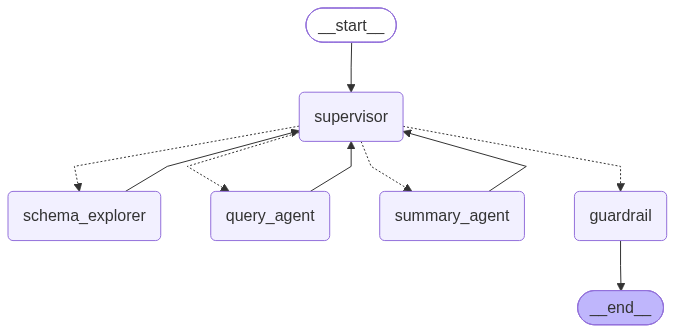

In [0]:
if not globals().get("_LANGGRAPH_LIBRARY_MODE"):
    from IPython.display import Image, display
    display(Image(multi_agent.get_graph().draw_mermaid_png()))
else:
    print("Skipping diagram render (library mode)")

In [0]:
if not globals().get("_LANGGRAPH_LIBRARY_MODE"):
    result = multi_agent.invoke(
        {
            "messages": [
                HumanMessage(
                    content=(
                        "For the table bdc_share_cash_flow.cashflow.cashflow, "
                        "first get its schema, then query the top 5 company codes by total AmountInGlobalCurrency, "
                        "and finally profile the table to show row counts and null rates."
                    )
                )
            ]
        },
        config={"recursion_limit": 100},
    )

    for msg in result["messages"]:
        print(f"[{msg.type.upper()}] {msg.content[:500]}")
        print("—" * 60)
else:
    print("Skipping test invocation (library mode)")

[HUMAN] For the table bdc_share_cash_flow.cashflow.cashflow, first get its schema, then query the top 5 company codes by total AmountInGlobalCurrency, and finally profile the table to show row counts and null rates.
————————————————————————————————————————————————————————————
[AI] 
————————————————————————————————————————————————————————————
[TOOL] {"table": "bdc_share_cash_flow.cashflow.cashflow", "columns": [{"name": "CashFlowID", "type": "string"}, {"name": "CshFlwValdtyStrtDteTmeVal", "type": "decimal(21,7)"}, {"name": "CompanyCode", "type": "string"}, {"name": "TransactionDate", "type": "date"}, {"name": "PostingDate", "type": "date"}, {"name": "TransactionCurrency", "type": "string"}, {"name": "AmountInTransactionCurrency", "type": "decimal(34,4)"}, {"name": "CompanyCodeCurrency", "type": "string"}, {"name": "AmountInCompanyCodeCurre
————————————————————————————————————————————————————————————
[AI] 
————————————————————————————————————————————————————————————
[TOOL] {"rows": [{"C

In [0]:
if not globals().get("_LANGGRAPH_LIBRARY_MODE"):
    # Adjust the prompt to match the Delta Shares available in your environment
    result = multi_agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="List all available catalogs and describe what tables each one contains."
            )
        ]
    },
        config={"recursion_limit": 100},
    )

    for msg in result["messages"]:
        print(f"[{msg.type.upper()}] {msg.content[:500]}")
        print("\u2014" * 60)
else:
    print("Skipping demo invocation (library mode)")

[HUMAN] List all available catalogs and describe what tables each one contains.
————————————————————————————————————————————————————————————
[AI] 
————————————————————————————————————————————————————————————
[TOOL] {"catalogs": ["bdc_share_cash_flow", "bdc_share_costcenter", "bdc_share_customer", "bdc_share_glaccount", "bdc_share_journal_entry", "bdc_share_supplier", "bdc_share_vendorperformance", "cashflow_data_product", "company_code_data_product", "companycode_share", "product_share", "samples", "system", "workspace"]}
————————————————————————————————————————————————————————————
[AI] 
————————————————————————————————————————————————————————————
[TOOL] {"catalog": "bdc_share_cash_flow", "schemas": [{"schema": "cashflow", "tables": ["cashflow", "cashflowforecast"]}, {"schema": "information_schema", "tables": ["abac_policy_definitions", "catalog_privileges", "catalog_tags", "catalogs", "check_constraints", "column_masks", "column_tags", "columns", "constraint_column_usage", "constraint